<!-- Reemplaza USUARIO/REPO por tu repositorio para activar el badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/05_canal_youtube_epsilon_delta.ipynb)

# ¿Por qué mi canal de YouTube se resiste a morir?

**Análisis exploratorio de la biblioteca de un canal educativo**
*235 videos · 441.801 visualizaciones · 23.106 horas de reproducción · 100 % crecimiento orgánico*

Luis Javier Rubio Hernández
Canal: ε–δ Matemáticas para ciencias e ingenierías

---

En 2009 creé un canal de YouTube casi por accidente y permaneció vacío once años. El 25 de marzo
de 2020, con el aislamiento preventivo obligatorio, se convirtió en la forma de hacer llegar mis
clases a mis estudiantes. Después lo abandoné. Los datos dicen que algo sigue funcionando.

La pregunta que motiva este análisis es concreta: ¿vale la pena un canal con 2.588 suscriptores
que no actualizo? ¿Es solo inercia, o hay demanda real detrás?

**Advertencia metodológica.** Este cuaderno usa el reporte de *contenido* de YouTube Studio: una
fila por video con sus métricas acumuladas. Con eso se pueden estudiar concentración, CTR,
formato y retención. **No** se puede estudiar estacionalidad ni evolución anual: eso requiere el
reporte por fecha, que se integra en la sección 7 cuando esté disponible. Las conclusiones se
limitan a lo que el dato permite sostener.

## 0. Configuración y carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

AZUL, GRIS, TEXTO, GRIS_OSC, ROJO = "#0073B1", "#D4D4D4", "#333333", "#767676", "#C0392B"

mpl.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.8),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": GRIS_OSC, "axes.titlecolor": TEXTO,
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "xtick.color": GRIS_OSC, "ytick.color": GRIS_OSC,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "grid.color": "#EEEEEE",
})
pd.set_option("display.width", 150)

In [2]:
# Reemplaza USUARIO/REPO por tu repositorio. La copia local sirve de respaldo.
URL = ("https://raw.githubusercontent.com/USUARIO/REPO/main/datos/"
       "youtube_epsilon_delta_videos.csv")
LOCAL = "youtube_epsilon_delta_videos.csv"

try:
    bruto = pd.read_csv(URL)
    print("Origen: repositorio remoto")
except Exception:
    bruto = pd.read_csv(LOCAL)
    print("Origen: copia local junto al cuaderno")

# La primera fila del reporte de YouTube Studio es el agregado del canal, no un video
total = bruto[bruto["Contenido"] == "Total"].iloc[0]
v = bruto[bruto["Contenido"] != "Total"].copy().reset_index(drop=True)

v = v.rename(columns={
    "Título del vídeo": "titulo", "Hora de publicación del vídeo": "publicado",
    "Duración": "duracion_s", "Visualizaciones": "views",
    "Tiempo de visualización (horas)": "horas", "Suscriptores": "subs",
    "Ingresos estimados (USD)": "ingresos", "Impresiones": "impresiones",
    "Porcentaje de clics de las impresiones (%)": "ctr",
})
v["publicado"] = pd.to_datetime(v["publicado"], format="%b %d, %Y", errors="coerce")
v["duracion_min"] = v["duracion_s"]/60

print(f"Videos en la biblioteca: {len(v)}")
print(f"Período de publicación : {v['publicado'].min():%b %Y} – {v['publicado'].max():%b %Y}")

Origen: copia local junto al cuaderno
Videos en la biblioteca: 235
Período de publicación : Mar 2020 – Feb 2026


## 1. Las cifras del canal

In [3]:
metricas = pd.Series({
    "Visualizaciones": total["Visualizaciones"],
    "Horas de reproducción": total["Tiempo de visualización (horas)"],
    "Suscriptores ganados": total["Suscriptores"],
    "Impresiones": total["Impresiones"],
    "CTR global (%)": total["Porcentaje de clics de las impresiones (%)"],
    "Ingresos estimados (USD)": total["Ingresos estimados (USD)"],
})
print(metricas.apply(lambda x: f"{x:,.2f}").to_string())

# El total del reporte debe coincidir con la suma por video: verificación elemental
dif = total["Visualizaciones"] - v["views"].sum()
print(f"\nSuma de views por video: {v['views'].sum():,}  "
      f"(reporte: {total['Visualizaciones']:,.0f}, diferencia de {dif:,.0f})")
print("La diferencia corresponde a contenido que ya no figura en la biblioteca —videos")
print("eliminados o privados— cuyas visualizaciones siguen contando en el total del canal.")
print(f"Suscriptores por cada 1.000 visualizaciones: "
      f"{1000*v['subs'].sum()/v['views'].sum():.2f}")
print(f"Ingreso por cada 1.000 visualizaciones: "
      f"{1000*v['ingresos'].sum()/v['views'].sum():.3f} USD")

Visualizaciones               441,801.00
Horas de reproducción          23,105.54
Suscriptores ganados            2,588.00
Impresiones                 4,547,523.00
CTR global (%)                      5.33
Ingresos estimados (USD)          231.57

Suma de views por video: 441,736  (reporte: 441,801, diferencia de 65)
La diferencia corresponde a contenido que ya no figura en la biblioteca —videos
eliminados o privados— cuyas visualizaciones siguen contando en el total del canal.
Suscriptores por cada 1.000 visualizaciones: 4.31
Ingreso por cada 1.000 visualizaciones: 0.524 USD


## 2. Calidad del dato

El reporte de Studio no es un archivo limpio: trae campos vacíos con significado y filas que no
son contenido publicado en sentido estricto.

In [4]:
sin_fecha = v["publicado"].isna()
sin_ctr = v["ctr"].isna()
sin_impresiones = (v["impresiones"] == 0)

print(f"Videos sin fecha de publicación : {sin_fecha.sum()} "
      f"({100*sin_fecha.mean():.1f} %)")
print(f"Videos sin CTR informado        : {sin_ctr.sum()}")
print(f"Videos con cero impresiones     : {sin_impresiones.sum()}")

print("\nLos videos sin fecha son, casi todos, grabaciones de sesiones en vivo:")
print(v.loc[sin_fecha, ["titulo", "duracion_min", "views"]]
       .assign(duracion_min=lambda t: t["duracion_min"].round(0))
       .head(6).to_string(index=False))
print("\nNo son contenido editado para el canal, y su duración y desempeño lo reflejan.")
print(f"Duración mediana de esas grabaciones: "
      f"{v.loc[sin_fecha,'duracion_min'].median():.0f} min  |  "
      f"resto de la biblioteca: {v.loc[~sin_fecha,'duracion_min'].median():.0f} min")

Videos sin fecha de publicación : 22 (9.4 %)
Videos sin CTR informado        : 8
Videos con cero impresiones     : 8

Los videos sin fecha son, casi todos, grabaciones de sesiones en vivo:
                                                          titulo  duracion_min  views
Meet   Cálculo I GL1A Lorica   Google Chrome 2022 12 08 13 24 29         120.0     40
   Clase 26-05-2024 Sólidos de revolución-Cascarones cilíndricos         105.0      8
                                       Meet  2022-11-11 16 18 37         119.0      8
                                                        Sesión 2         131.0      8
                                                     21-feb-2024          80.0      7
  18-05-2020 Integración por partes e integrales trigonométricas         123.0      6

No son contenido editado para el canal, y su duración y desempeño lo reflejan.
Duración mediana de esas grabaciones: 94 min  |  resto de la biblioteca: 13 min


## 3. Concentración: la ley de Pareto en la biblioteca

La primera pregunta cuantitativa es cuánto del tráfico depende de cuántos videos. Se responde
con la curva de Lorenz y el coeficiente de Gini, en vez de con una afirmación aproximada.

In [5]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = x.size
    return (2*np.sum(np.arange(1, n+1)*x) - (n+1)*x.sum())/(n*x.sum())

orden = v.sort_values("views", ascending=False).reset_index(drop=True)
acum = orden["views"].cumsum()/orden["views"].sum()
n_80 = int((acum <= .80).sum()) + 1

print(f"Gini de las visualizaciones entre videos: {gini(v['views']):.3f}")
print(f"\nEl video más visto acumula el {100*orden['views'].iloc[0]/orden['views'].sum():.1f} % "
      f"de todo el tráfico del canal.")
print(f"Los 10 primeros ({100*10/len(v):.1f} % de la biblioteca) generan el "
      f"{100*orden['views'].head(10).sum()/orden['views'].sum():.1f} % de las views.")
print(f"El 80 % del tráfico lo producen {n_80} videos: el {100*n_80/len(v):.1f} % de la "
      f"biblioteca.")
print(f"\nLa mitad menos vista de la biblioteca ({len(v)//2} videos) aporta el "
      f"{100*orden['views'].tail(len(v)//2).sum()/orden['views'].sum():.1f} %.")

Gini de las visualizaciones entre videos: 0.795

El video más visto acumula el 21.6 % de todo el tráfico del canal.
Los 10 primeros (4.3 % de la biblioteca) generan el 56.7 % de las views.
El 80 % del tráfico lo producen 37 videos: el 15.7 % de la biblioteca.

La mitad menos vista de la biblioteca (117 videos) aporta el 5.0 %.


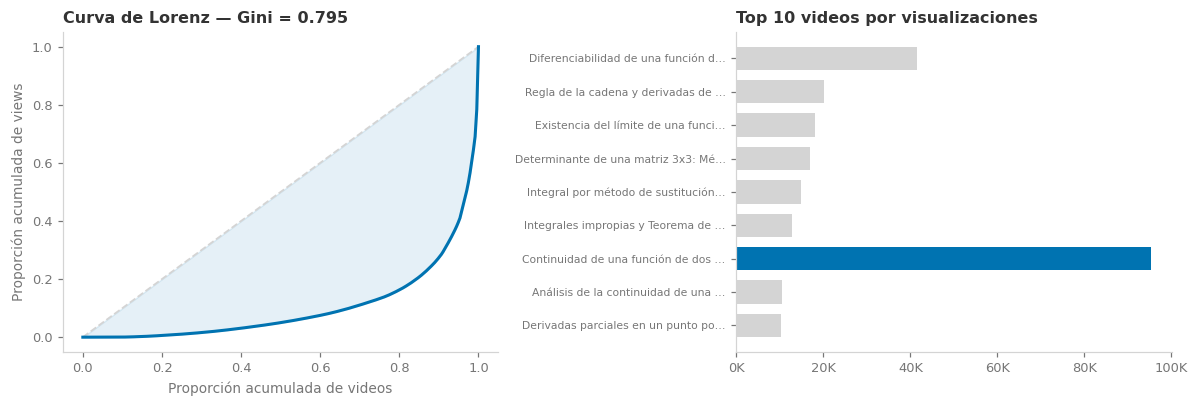

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

p_videos = np.linspace(0, 1, len(v)+1)
p_views = np.insert(np.cumsum(np.sort(v["views"]))/v["views"].sum(), 0, 0)
ax[0].plot([0, 1], [0, 1], color=GRIS, ls="--", lw=1.2)
ax[0].plot(p_videos, p_views, color=AZUL, lw=2)
ax[0].fill_between(p_videos, p_views, p_videos, color=AZUL, alpha=.10)
ax[0].set_xlabel("Proporción acumulada de videos")
ax[0].set_ylabel("Proporción acumulada de views")
ax[0].set_title(f"Curva de Lorenz — Gini = {gini(v['views']):.3f}")

top10 = orden.head(10).iloc[::-1]
cortos = [t[:34] + "…" if len(t) > 34 else t for t in top10["titulo"]]
colores = [AZUL if i == len(top10)-1 else GRIS for i in range(len(top10))]
ax[1].barh(cortos, top10["views"], color=colores, height=.7)
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:,.0f}K"))
ax[1].set_title("Top 10 videos por visualizaciones")
ax[1].tick_params(axis="y", labelsize=7)

fig.tight_layout(); plt.show()

In [7]:
tabla = orden.head(5)[["titulo", "views", "ctr", "subs", "duracion_min"]].copy()
tabla["% del canal"] = (100*tabla["views"]/v["views"].sum()).round(1)
tabla["duracion_min"] = tabla["duracion_min"].round(0)
tabla["titulo"] = tabla["titulo"].str.slice(0, 55)
tabla.rename(columns={"titulo": "Video", "views": "Views", "ctr": "CTR (%)",
                      "subs": "Subs", "duracion_min": "Min"})

,Video,Views,CTR (%),Subs,Min,% del canal
0,Continuidad de una función de dos variables,95310,9.31,283,25.0,21.6
1,Diferenciabilidad de una función de dos variables,41491,9.36,113,20.0,9.4
2,Regla de la cadena y derivadas de segundo orden,20096,5.08,80,27.0,4.5
3,Existencia del límite de una función de dos va...,17955,8.22,73,36.0,4.1
4,Determinante de una matriz 3x3: Método de cofa...,16883,3.11,45,1.0,3.8


Los cinco primeros son temas de cálculo en varias variables y álgebra lineal: continuidad,
diferenciabilidad, regla de la cadena, teorema del sándwich, determinantes por cofactores.
Contenido que se enseña en la mayoría de programas de ingeniería y ciencias, cada semestre, cada
año. La demanda se renueva sola.

## 4. CTR: ¿confirma relevancia?

El CTR mide qué proporción de quienes ven la miniatura hacen clic. El informe original citaba el
9,3 % del video principal frente a un promedio de categoría del 4,5 %. Conviene separar tres
cosas que suelen mezclarse: el CTR de un video, el CTR promedio de la biblioteca y el CTR global
del canal, que es un promedio ponderado por impresiones.

In [8]:
ctr = v.dropna(subset=["ctr"])
ctr_ponderado = 100*(ctr["ctr"]/100*ctr["impresiones"]).sum()/ctr["impresiones"].sum()

print(f"CTR del video principal          : {orden['ctr'].iloc[0]:.2f} %")
print(f"CTR medio simple de la biblioteca: {ctr['ctr'].mean():.2f} %")
print(f"CTR mediano de la biblioteca     : {ctr['ctr'].median():.2f} %")
print(f"CTR ponderado por impresiones    : {ctr_ponderado:.2f} %  "
      f"(reporte de Studio: {total['Porcentaje de clics de las impresiones (%)']:.2f} %)")
print(f"\nLa diferencia entre {ctr['ctr'].mean():.2f} % y {ctr_ponderado:.2f} % no es un error: "
      f"el promedio simple trata\nigual a un video con 600.000 impresiones y a uno con 200. "
      f"El ponderado es el que describe\nel canal; el simple describe el video típico.")
print(f"\nVideos con CTR por encima del 5 %: {(ctr['ctr'] > 5).sum()} de {len(ctr)} "
      f"({100*(ctr['ctr'] > 5).mean():.0f} %)")

CTR del video principal          : 9.31 %
CTR medio simple de la biblioteca: 3.32 %
CTR mediano de la biblioteca     : 2.56 %
CTR ponderado por impresiones    : 5.33 %  (reporte de Studio: 5.33 %)

La diferencia entre 3.32 % y 5.33 % no es un error: el promedio simple trata
igual a un video con 600.000 impresiones y a uno con 200. El ponderado es el que describe
el canal; el simple describe el video típico.

Videos con CTR por encima del 5 %: 41 de 227 (18 %)


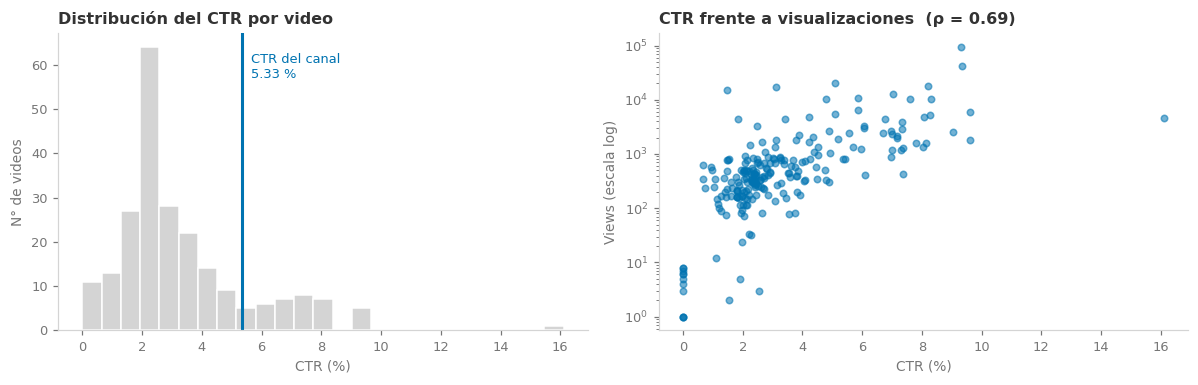

Spearman CTR ~ views        : ρ = 0.693  (p = 8.4e-34)
Spearman impresiones ~ views: ρ = 0.913  (p = 1.8e-92)

La asociación entre impresiones y views es casi perfecta, y era esperable: las views
son impresiones por CTR. El dato informativo es que el CTR también correlaciona fuerte,
lo que indica que los videos que el algoritmo muestra más son también los que la gente
elige más. Ninguna de las dos correlaciones establece causalidad en un sentido u otro.


In [9]:
rho_ctr, p_ctr = stats.spearmanr(ctr["ctr"], ctr["views"])
rho_imp, p_imp = stats.spearmanr(v["impresiones"], v["views"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].hist(ctr["ctr"], bins=25, color=GRIS, edgecolor="white")
ax[0].axvline(ctr_ponderado, color=AZUL, lw=2)
ax[0].text(ctr_ponderado+.3, ax[0].get_ylim()[1]*.85, f"CTR del canal\n{ctr_ponderado:.2f} %",
           color=AZUL, fontsize=8.5)
ax[0].set_xlabel("CTR (%)"); ax[0].set_ylabel("N° de videos")
ax[0].set_title("Distribución del CTR por video")

ax[1].scatter(ctr["ctr"], ctr["views"], s=18, alpha=.55, color=AZUL)
ax[1].set_yscale("log")
ax[1].set_xlabel("CTR (%)"); ax[1].set_ylabel("Views (escala log)")
ax[1].set_title(f"CTR frente a visualizaciones  (ρ = {rho_ctr:.2f})")

fig.tight_layout(); plt.show()

print(f"Spearman CTR ~ views        : ρ = {rho_ctr:.3f}  (p = {p_ctr:.1e})")
print(f"Spearman impresiones ~ views: ρ = {rho_imp:.3f}  (p = {p_imp:.1e})")
print("\nLa asociación entre impresiones y views es casi perfecta, y era esperable: las views")
print("son impresiones por CTR. El dato informativo es que el CTR también correlaciona fuerte,")
print("lo que indica que los videos que el algoritmo muestra más son también los que la gente")
print("elige más. Ninguna de las dos correlaciones establece causalidad en un sentido u otro.")

## 5. El formato: dónde el informe original se equivocó

La afirmación del informe era que los videos de 20 a 30 minutos promedian 5.518 views frente a
150 de los de más de 60 minutos, y que eso demuestra cuál es el formato ideal. La media es
correcta. La conclusión no se sostiene, y conviene verlo con detalle porque es exactamente el
tipo de error que un análisis con cola pesada produce.

In [10]:
cortes = [0, 600, 1200, 1800, 2700, 3600, np.inf]
etiquetas = ["0–10", "10–20", "20–30", "30–45", "45–60", "60+"]
v["franja"] = pd.cut(v["duracion_s"], bins=cortes, labels=etiquetas)

franjas = v.groupby("franja", observed=True)["views"].agg(
    videos="count", media="mean", mediana="median", maximo="max").round(0)
print(franjas.to_string())

        videos   media  mediana  maximo
franja                                 
0–10        86  1490.0    436.0   16883
10–20       65   951.0    363.0   12697
20–30       37  5518.0    677.0   95310
30–45       18  2316.0    864.0   17955
45–60        6   407.0    488.0     779
60+         23   150.0      6.0    1642


In [11]:
# ¿Cuánto de la media del tramo 20–30 depende de unos pocos videos?
x = v.loc[v["franja"] == "20–30", "views"].to_numpy()
rng = np.random.default_rng(0)
boot = np.array([rng.choice(x, x.size, replace=True).mean() for _ in range(5000)])
ic = np.percentile(boot, [2.5, 97.5])

print(f"Tramo 20–30 min: {x.size} videos, media {x.mean():,.0f} views")
print(f"  IC bootstrap al 95 % de la media: [{ic[0]:,.0f} ; {ic[1]:,.0f}]")
print(f"  Media excluyendo los dos videos más vistos: {np.sort(x)[:-2].mean():,.0f}")
print(f"  Mediana: {np.median(x):,.0f}")
print("\nEl intervalo de confianza abarca casi un orden de magnitud y la media cae un 65 % al")
print("quitar dos videos de treinta y siete. La media de ese tramo no describe un formato:")
print("describe dos videos que se volvieron populares y que además duran entre 20 y 30 minutos.")

grupos = [v.loc[v["franja"] == e, "views"].dropna() for e in etiquetas]
H, p = stats.kruskal(*grupos)
k, n = len(grupos), sum(len(g) for g in grupos)
print(f"\nKruskal-Wallis sobre las seis franjas: H = {H:.2f}, p = {p:.2e}, "
      f"epsilon² = {(H-k+1)/(n-k):.3f}")
print("Las franjas sí difieren, pero la diferencia robusta está en otro lugar del que sugería")
print("el informe. Con medianas, el tramo 30–45 supera al de 20–30, y ambos superan a los")
print("videos cortos. El contraste realmente marcado es el de los videos de más de 60 minutos.")

Tramo 20–30 min: 37 videos, media 5,518 views
  IC bootstrap al 95 % de la media: [1,324 ; 12,045]
  Media excluyendo los dos videos más vistos: 1,925
  Mediana: 677

El intervalo de confianza abarca casi un orden de magnitud y la media cae un 65 % al
quitar dos videos de treinta y siete. La media de ese tramo no describe un formato:
describe dos videos que se volvieron populares y que además duran entre 20 y 30 minutos.

Kruskal-Wallis sobre las seis franjas: H = 40.49, p = 1.19e-07, epsilon² = 0.155
Las franjas sí difieren, pero la diferencia robusta está en otro lugar del que sugería
el informe. Con medianas, el tramo 30–45 supera al de 20–30, y ambos superan a los
videos cortos. El contraste realmente marcado es el de los videos de más de 60 minutos.


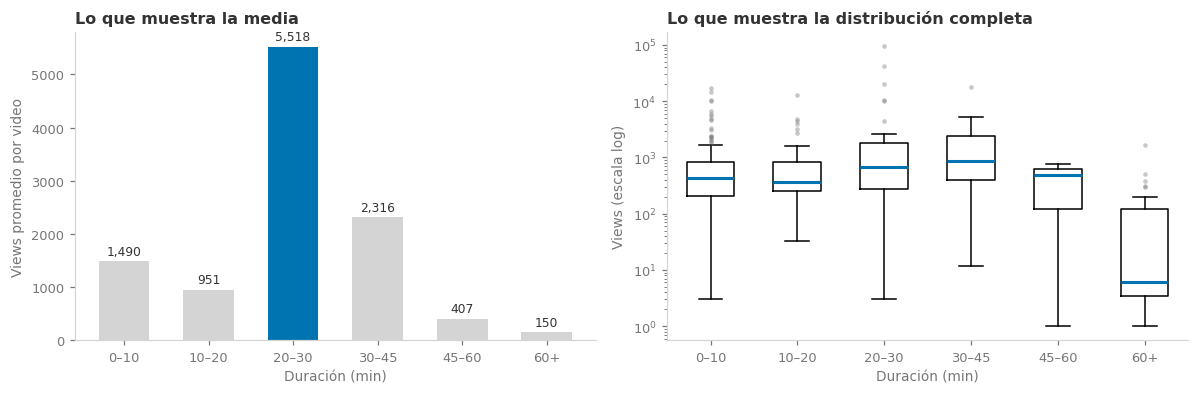

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))

ax[0].bar(franjas.index.astype(str), franjas["media"],
          color=[AZUL if e == "20–30" else GRIS for e in franjas.index], width=.6)
for i, val in enumerate(franjas["media"]):
    ax[0].text(i, val+120, f"{val:,.0f}", ha="center", fontsize=8, color=TEXTO)
ax[0].set_ylabel("Views promedio por video")
ax[0].set_title("Lo que muestra la media")
ax[0].set_xlabel("Duración (min)")

datos_box = [v.loc[v["franja"] == e, "views"].dropna() for e in etiquetas]
bp = ax[1].boxplot(datos_box, tick_labels=etiquetas, showfliers=True, widths=.55,
                   medianprops=dict(color=AZUL, lw=2),
                   flierprops=dict(marker="o", ms=3, alpha=.4,
                                   markerfacecolor=GRIS_OSC, markeredgecolor="none"))
ax[1].set_yscale("log")
ax[1].set_ylabel("Views (escala log)"); ax[1].set_xlabel("Duración (min)")
ax[1].set_title("Lo que muestra la distribución completa")

fig.tight_layout(); plt.show()

La conclusión honesta que el dato sí sostiene es más modesta y sigue siendo útil: **las
grabaciones de clase completas no funcionan**. Su mediana es de unas pocas visualizaciones frente
a varios cientos en el resto de la biblioteca. Un tema, un problema, explicado en menos de
cuarenta y cinco minutos, rinde consistentemente mejor que una sesión de noventa. Lo que no puede
afirmarse con estos datos es que exista una franja óptima de veinte a treinta minutos.

## 6. Retención: la duración tiene un costo medible

El reporte no trae el porcentaje de retención, pero sí permite estimarlo. Si el tiempo de
reproducción total se divide entre las visualizaciones, se obtiene la duración media vista; al
dividirla por la duración del video se obtiene la fracción vista:

$$\text{retención} = \frac{\text{horas} \times 3600}{\text{views} \times \text{duración}}$$

In [13]:
v["retencion"] = v["horas"]*3600/(v["views"]*v["duracion_s"])

rho_r, p_r = stats.spearmanr(v["duracion_min"], v["retencion"])
print(f"Retención mediana de la biblioteca: {v['retencion'].median():.1%}")
print(f"Duración media vista, mediana     : "
      f"{(v['horas']*60/v['views']).median():.1f} minutos")
print(f"\nSpearman duración ~ retención: ρ = {rho_r:.3f}  (p = {p_r:.1e})")

por_franja = v.groupby("franja", observed=True).agg(
    retencion_mediana=("retencion", "median"),
    minutos_vistos=("duracion_min", lambda s: np.nan))
por_franja["minutos_vistos"] = v.groupby("franja", observed=True).apply(
    lambda g: (g["horas"]*60/g["views"]).median(), include_groups=False)
print("\n" + (por_franja.assign(
    retencion_mediana=lambda t: (100*t["retencion_mediana"]).round(1),
    minutos_vistos=lambda t: t["minutos_vistos"].round(1))).to_string())

Retención mediana de la biblioteca: 23.2%
Duración media vista, mediana     : 2.9 minutos

Spearman duración ~ retención: ρ = -0.829  (p = 9.5e-61)

        retencion_mediana  minutos_vistos
franja                                   
0–10                 34.7             1.8
10–20                23.3             3.2
20–30                17.0             4.1
30–45                12.7             5.1
45–60                11.5             5.6
60+                   7.9             5.4


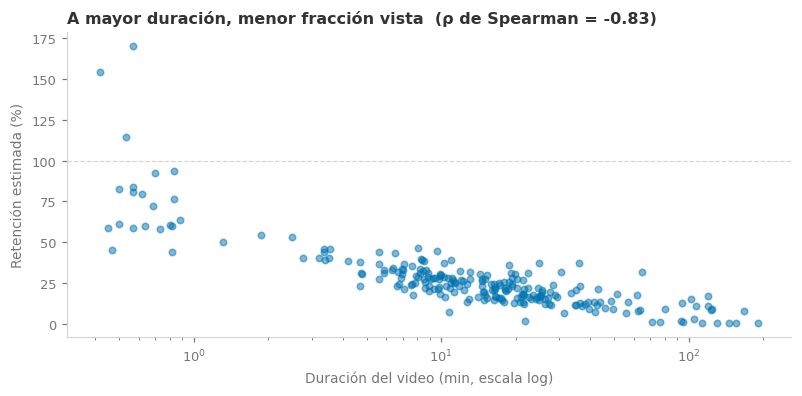

La relación es de las más fuertes de todo el análisis. Un video largo no solo se ve
menos: del que se ve, se ve una fracción mucho menor. Los pocos valores por encima del
100 % corresponden a videos muy cortos con reproducciones repetidas.


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.scatter(v["duracion_min"], 100*v["retencion"], s=18, alpha=.5, color=AZUL)
ax.set_xscale("log")
ax.set_xlabel("Duración del video (min, escala log)")
ax.set_ylabel("Retención estimada (%)")
ax.set_title(f"A mayor duración, menor fracción vista  (ρ de Spearman = {rho_r:.2f})")
ax.axhline(100, color=GRIS, ls="--", lw=.8)
plt.show()

print("La relación es de las más fuertes de todo el análisis. Un video largo no solo se ve")
print("menos: del que se ve, se ve una fracción mucho menor. Los pocos valores por encima del")
print("100 % corresponden a videos muy cortos con reproducciones repetidas.")

## 7. Estacionalidad — pendiente

El hallazgo central del informe original era que las visualizaciones suben en abril-mayo y
septiembre-octubre, y caen en julio y diciembre-enero, siguiendo el calendario académico. **Ese
análisis no se puede hacer con este archivo**: el reporte de contenido trae totales acumulados
por video, sin ninguna dimensión temporal de consumo.

Para completarlo hace falta el reporte **Visualizaciones por fecha** de YouTube Studio (Analytics
→ Avanzado → pestaña Fecha → Exportar). Con ese archivo, esta sección debe incluir:

1. Serie diaria de visualizaciones y su agregación mensual.
2. Descomposición estacional (STL o medias móviles) para separar tendencia de estacionalidad.
3. Contraste formal de la hipótesis académica: comparar los meses de parciales contra el resto
   con Kruskal-Wallis o una prueba de permutación sobre las medias mensuales, en lugar de
   afirmar el patrón a partir de la inspección visual del gráfico.
4. Comparación interanual controlada por el número de videos publicados en cada período.

Sin ese contraste, la estacionalidad es una lectura plausible de un gráfico, no un resultado.

## 8. Conclusiones

**Lo que el dato sostiene.**

La biblioteca es fuertemente concentrada: el índice de Gini de las visualizaciones entre videos
es de 0,795 y un solo video acumula el 21,6 % del tráfico del canal. La mitad menos vista de la
biblioteca aporta el 5 % de las visualizaciones. El 80 % de las
visualizaciones proviene de menos del 16 % de los videos.

El CTR global del canal, ponderado por impresiones, está por encima del CTR mediano de sus
propios videos, lo que indica que los videos con más exposición son también los que mejor
convierten la miniatura en clic.

Las grabaciones de clase completas —sesiones de más de una hora, muchas de ellas sin fecha de
publicación en el reporte— son el segmento con peor desempeño de toda la biblioteca, tanto en
visualizaciones como en retención.

La retención cae de forma pronunciada con la duración. Es la asociación más fuerte del análisis.

**Lo que el dato no sostiene.**

Que exista una franja óptima de veinte a treinta minutos. La media de ese tramo depende de dos
videos entre treinta y siete, y su intervalo de confianza bootstrap abarca casi un orden de
magnitud.

Que el canal tenga una estacionalidad alineada con el calendario académico. Es una hipótesis
razonable y probablemente cierta, pero exige el reporte por fecha y un contraste formal.

**Lo que queda en pie.** Detrás de 441.801 visualizaciones y 23.106 horas hay personas que
buscaban entender continuidad, diferenciabilidad o la regla de la cadena y encontraron una
explicación que les funcionó. Los temas del top 10 se enseñan cada semestre en cualquier programa
de ingeniería, y esa demanda se renueva sola. Eso no lo dice un contraste de hipótesis: lo dice
el hecho de que el canal siga recibiendo tráfico sin contenido nuevo.

---

### Fuentes

YouTube Studio Analytics — reporte de contenido exportado de la plataforma (período completo).

Nussbaumer Knaflic, C. (2015). *Storytelling with Data: A Data Visualization Guide for Business
Professionals*. Wiley.

Luis Javier Rubio Hernández